---
title: "05 — Patching: grid → process → stitch"
---

# Patching — grid sample → per-chip op → stitch

This notebook is the **gridding & patching** walkthrough: take one
large Sentinel-2 scene that is too big to feed to a tile-sized model
(or a memory-constrained operator), break it into overlapping chips
with `geopatcher`'s `SpatialPatcher`, run a per-chip operator over
each, then blend the results back into a seamless full-resolution
raster.

`geotoolz.patch_ops` ships three thin `Operator` wrappers around
`geopatcher` so the whole flow composes inside a single
`Sequential`:

| Stage | Operator | What it does |
|---|---|---|
| split  | `gz.patch_ops.GridSampler(patcher)`            | `Field → list[Patch]` |
| apply  | `gz.patch_ops.ApplyToChips(op)`                | `list[Patch] → list[Patch]` (runs `op` on each `patch.data`) |
| stitch | `gz.patch_ops.Stitch(aggregation, domain=…)`   | `list[Patch] → Field` (overlap-add or majority-vote merge) |

**Scenario.**

| | |
|---|---|
| AOI bbox (EPSG:4326) | `(-120.10, 38.92, -119.93, 39.27)` (Lake Tahoe main body) |
| Date range | `2024-06-01` to `2024-07-15` |
| STAC | Microsoft Planetary Computer (`sentinel-2-l2a`) |
| MGRS tile | `10SGJ` |
| Per-chip op | `gz.radiometry.DNToReflectance | gz.indices.NDVI` (BGRN stack → NDVI) |
| Patcher | 256 × 256 chips, 64-pixel stride overlap, Hann window |
| Stitching | `SpatialOverlapAdd` — overlap-add blend across windowed chips |

In [1]:
import geopatcher as gp
import geotoolz as gz
import matplotlib.pyplot as plt
import numpy as np
import planetary_computer
import pystac_client
import rioxarray
from geopatcher.fields import RasterField
from georeader.geotensor import GeoTensor
from geotoolz.patch_ops import ApplyToChips, GridSampler, Stitch
from rasterio.enums import Resampling

## 1. Load one Sentinel-2 scene

Same plumbing as the [Lake Tahoe operators notebook](03_operators_lake_tahoe.ipynb)
— STAC search → `rioxarray` → wrap as a `GeoTensor`. Here we stack
Red + NIR into one 2-band carrier; that's what the per-chip operator
expects.

In [2]:
BBOX = (-120.10, 38.92, -119.93, 39.27)

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)
items = sorted(
    catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=BBOX,
        datetime="2024-06-01/2024-07-15",
        query={
            "eo:cloud_cover": {"lt": 5},
            "s2:mgrs_tile": {"eq": "10SGJ"},
        },
    ).items(),
    key=lambda x: x.properties["eo:cloud_cover"],
)
item = items[0]
print(f"using {item.id}  cloud_cover={item.properties['eo:cloud_cover']:.2f}%")

using S2B_MSIL2A_20240614T183919_R070_T10SGJ_20240615T003207  cloud_cover=0.01%


In [3]:
def _load(key, *, ref=None, resampling=Resampling.bilinear):
    da = rioxarray.open_rasterio(item.assets[key].href, masked=False)
    da = da.squeeze("band", drop=True).rio.clip_box(*BBOX, crs="EPSG:4326")
    if ref is not None:
        da = da.rio.reproject_match(ref, resampling=resampling)
    return da


red = _load("B04")
nir = _load("B08", ref=red)
rn_arr = np.stack([red.values, nir.values], axis=0).astype("uint16")
rn_gt = GeoTensor(
    values=rn_arr,
    transform=red.rio.transform(),
    crs=red.rio.crs,
    fill_value_default=0,
)
print(f"rn_gt: shape={rn_gt.shape}  dtype={rn_gt.dtype}")

rn_gt: shape=(2, 3935, 1599)  dtype=uint16


## 2. Wrap as a `Field`

`geopatcher`'s `SpatialPatcher` operates on **`Field`** objects.
`RasterField` is the thin adapter for any `georeader` reader —
including a `GeoTensor`, which doubles as one. The same `Field`
protocol generalises to `XarrayField`, `RioXarrayField`,
`GeoPandasField`, `XvecField`, `DaskField` for non-raster sources.

In [4]:
field = RasterField(reader=rn_gt)
print(f"field.domain.shape = {field.domain.shape}")
print(f"field.domain.bounds = {field.domain.bounds}")
print(f"field.domain.crs    = {field.domain.crs}")

field.domain.shape = (2, 3935, 1599)
field.domain.bounds = (750180.0, 4311890.0, 766170.0, 4351240.0)
field.domain.crs    = EPSG:32610


## 3. Build a `SpatialPatcher`

`SpatialPatcher` decomposes "how to slide a window over a Field"
into **four orthogonal axes**:

| Axis | Pick | Job |
|---|---|---|
| `geometry` | `SpatialRectangular(size=(256, 256))` | shape & size of each chip |
| `sampler`  | `SpatialRegularStride(step=(192, 192))` | where chips are placed (regular grid with 25 % overlap) |
| `window`   | `SpatialHann()` | the windowing function applied for blending |
| `aggregation` | `SpatialOverlapAdd()` | how overlapping chips combine on merge |

Swap any axis independently — `SpatialRegularStride` for tiling,
`SpatialPoissonDisk` for training-chip sampling, `SpatialBoxcar`
instead of `SpatialHann` to see seams, `SpatialHardVote` for
segmentation merges, etc.

In [5]:
patcher = gp.SpatialPatcher(
    geometry=gp.SpatialRectangular(size=(256, 256)),
    sampler=gp.SpatialRegularStride(step=(192, 192)),
    window=gp.SpatialHann(),
    aggregation=gp.SpatialOverlapAdd(),
)
patches = list(patcher.split(field))
print(f"split produced {len(patches)} chips of size {patches[0].data.shape}")

split produced 140 chips of size (2, 256, 256)


Visualise the patch grid: show one true-color preview of the scene
with chip anchors overlaid.

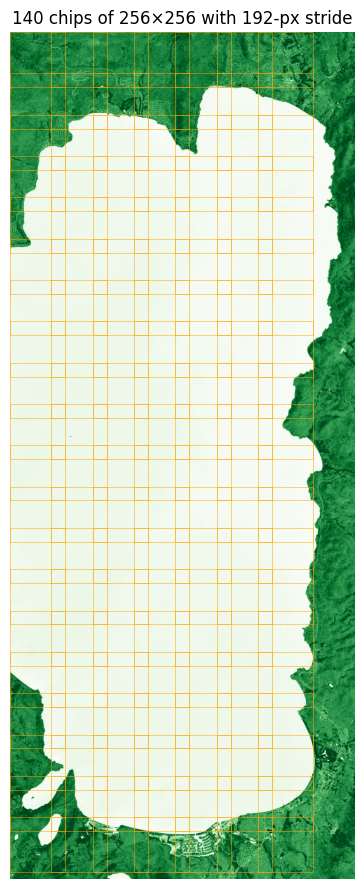

In [6]:
preview_pipe = gz.radiometry.DNToReflectance(scale=1e-4) | gz.radiometry.PercentileClip(
    p_min=2.0, p_max=98.0
)
preview = np.array(preview_pipe(rn_gt))  # cast to plain ndarray for matplotlib
nir_band = preview[1]  # B08 highlights vegetation
fig, ax = plt.subplots(figsize=(7, 11))
ax.imshow(nir_band, cmap="Greens", vmin=0, vmax=1)
# Overlay chip footprints. `Patch.indices` is a `rasterio.windows.Window`
# carrying col_off / row_off / width / height in pixel coordinates.
for p in patches:
    w = p.indices
    ax.add_patch(
        plt.Rectangle(
            (w.col_off, w.row_off),
            w.width,
            w.height,
            linewidth=0.5,
            edgecolor="orange",
            facecolor="none",
            alpha=0.7,
        )
    )
ax.set_title(f"{len(patches)} chips of 256×256 with 192-px stride")
ax.axis("off")
plt.show()

## 4. The full pipeline — `Sequential([GridSampler, ApplyToChips, Stitch])`

Per-chip operator: DN → reflectance → NDVI. Same `gz.radiometry` /
`gz.indices` ops we used for the full scene in the [Lake Tahoe
notebook](03_operators_lake_tahoe.ipynb), only now they execute inside
each chip. The patcher handles split + stitch.

In [7]:
per_chip = gz.radiometry.DNToReflectance(scale=1e-4) | gz.indices.NDVI(
    red_idx=0, nir_idx=1
)

pipeline = gz.Sequential(
    [
        GridSampler(patcher=patcher),
        ApplyToChips(operator=per_chip),
        Stitch(aggregation=patcher.aggregation, domain=field.domain),
    ]
)
print(pipeline)

ndvi_stitched = pipeline(field)
print(
    "stitched output:",
    np.asarray(ndvi_stitched).shape,
    np.asarray(ndvi_stitched).dtype,
)

Sequential([GridSampler(patcher={'geometry': {'class': 'SpatialRectangular', 'config': {'size': [256, 256]}}, 'sampler': {'class': 'SpatialRegularStride', 'config': {'step': [192, 192]}}, 'window': {'class': 'SpatialHann', 'config': {}}, 'aggregation': {'class': 'SpatialOverlapAdd', 'config': {'streaming': False, 'target_path': None, 'chunks': None, 'normalize_by_window': True}}}), ApplyToChips(operator={'class': 'Sequential', 'config': {'operators': [{'class': 'DNToReflectance', 'config': {'scale': 0.0001, 'offset': 0.0, 'axis': 0}}, {'class': 'NDVI', 'config': {'nir_idx': 1, 'red_idx': 0, 'axis': 0, 'eps': 1e-10}}]}}), Stitch(aggregation={'class': 'SpatialOverlapAdd', 'config': {'streaming': False, 'target_path': None, 'chunks': None, 'normalize_by_window': True}})])


stitched output: (2, 3935, 1599) float64


### A note on output shape

The field's spatial domain is `(2, H, W)` — two bands. `SpatialOverlapAdd`
merges the chip outputs into that same shape, so even though each chip's
NDVI is a single-channel `(256, 256)` map, the aggregation broadcasts
it back over the 2-band field shape. The two output channels are
identical NDVI replicas — we collapse to a single map by taking
channel 0.

In [8]:
ndvi_stitch_arr = np.asarray(ndvi_stitched)
if ndvi_stitch_arr.ndim == 3:
    print(
        "channels identical?",
        bool(np.allclose(ndvi_stitch_arr[0], ndvi_stitch_arr[1], equal_nan=True)),
    )
    ndvi_stitch_arr = ndvi_stitch_arr[0]
print("collapsed stitched shape:", ndvi_stitch_arr.shape)

channels identical? True
collapsed stitched shape: (3935, 1599)


## 5. Compare against the full-scene NDVI

Sanity check: the stitched per-chip NDVI should match the result of
running NDVI on the *whole* scene at once. They will agree across
the interior; edge effects appear at the field boundary where the
patcher's `boundary="drop"` policy leaves a margin of pixels
uncovered by any chip, and around the seam between non-overlapping
tile rows / columns.

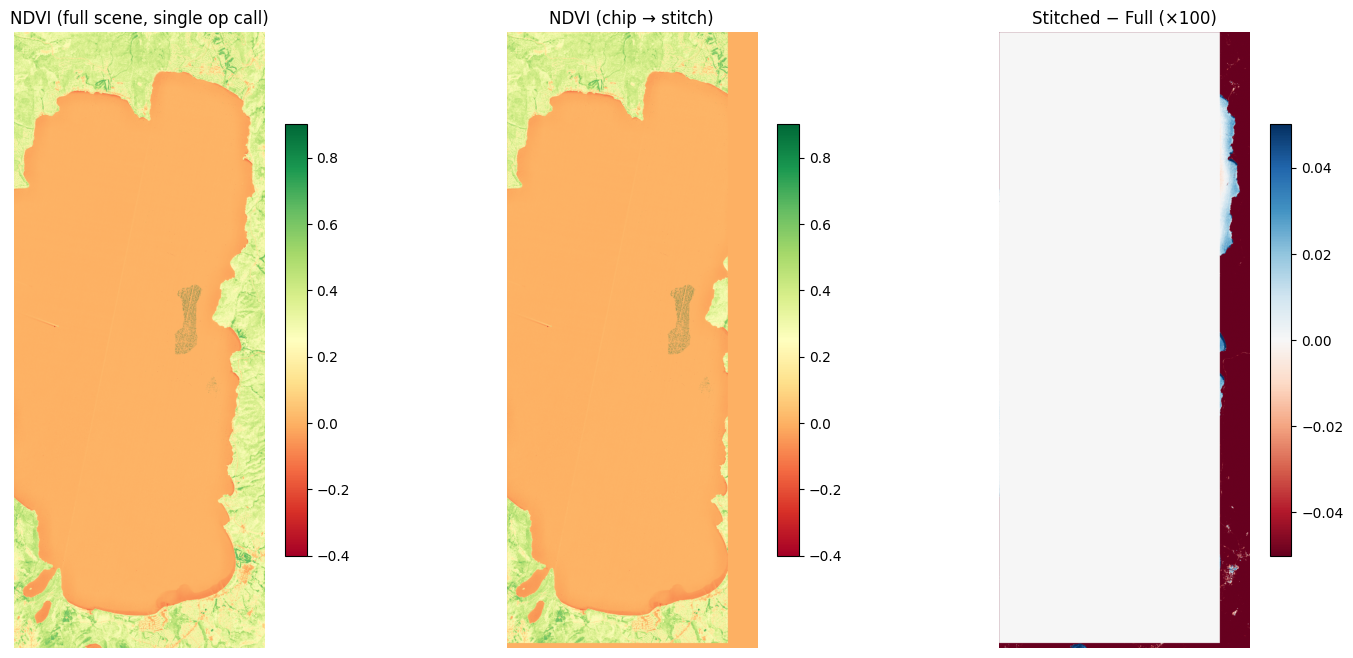

abs diff: mean=0.0378  max=1.0000


In [9]:
ndvi_full_arr = np.asarray(per_chip(rn_gt))
diff = ndvi_stitch_arr - ndvi_full_arr

fig, axes = plt.subplots(1, 3, figsize=(18, 8))
im0 = axes[0].imshow(ndvi_full_arr, cmap="RdYlGn", vmin=-0.4, vmax=0.9)
axes[0].set_title("NDVI (full scene, single op call)")
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], shrink=0.7)

im1 = axes[1].imshow(ndvi_stitch_arr, cmap="RdYlGn", vmin=-0.4, vmax=0.9)
axes[1].set_title("NDVI (chip → stitch)")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], shrink=0.7)

im2 = axes[2].imshow(diff, cmap="RdBu", vmin=-0.05, vmax=0.05)
axes[2].set_title("Stitched − Full (×100)")
axes[2].axis("off")
fig.colorbar(im2, ax=axes[2], shrink=0.7)
plt.show()

print(
    f"abs diff: mean={np.nanmean(np.abs(diff)):.4f}  max={np.nanmax(np.abs(diff)):.4f}"
)

## 6. Window choice matters — Hann vs Boxcar

The window controls how chip contributions are blended where they
overlap. A **Hann** window tapers smoothly to zero at the edges, so
overlap-add averages chip centres without leaving seams. A **Boxcar**
window is uniform — fast, but visible tile boundaries appear wherever
chips overlap unevenly (or, when they don't overlap, wherever per-chip
*content statistics* differ across the seam).

Swap one axis of the patcher, re-run the same `Sequential`, look at
the residual.

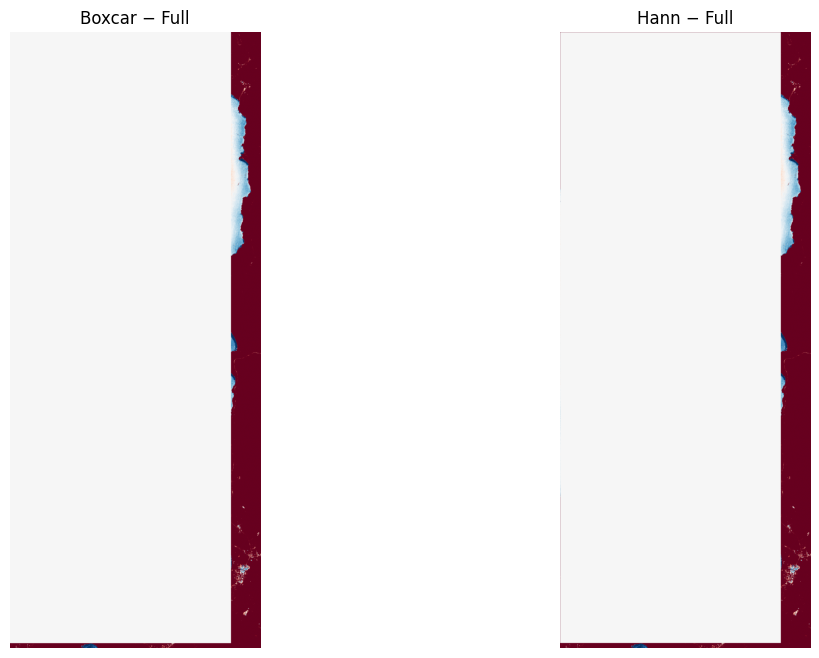

Boxcar abs diff: mean=0.0374
Hann   abs diff: mean=0.0378


In [10]:
boxcar_patcher = gp.SpatialPatcher(
    geometry=gp.SpatialRectangular(size=(256, 256)),
    sampler=gp.SpatialRegularStride(step=(192, 192)),
    window=gp.SpatialBoxcar(),
    aggregation=gp.SpatialOverlapAdd(),
)
boxcar_pipeline = gz.Sequential(
    [
        GridSampler(patcher=boxcar_patcher),
        ApplyToChips(operator=per_chip),
        Stitch(aggregation=boxcar_patcher.aggregation, domain=field.domain),
    ]
)
ndvi_boxcar = np.asarray(boxcar_pipeline(field))
if ndvi_boxcar.ndim == 3:
    ndvi_boxcar = ndvi_boxcar[0]  # collapse duplicated channels

fig, axes = plt.subplots(1, 2, figsize=(13, 8))
axes[0].imshow(ndvi_boxcar - ndvi_full_arr, cmap="RdBu", vmin=-0.05, vmax=0.05)
axes[0].set_title("Boxcar − Full")
axes[0].axis("off")

axes[1].imshow(ndvi_stitch_arr - ndvi_full_arr, cmap="RdBu", vmin=-0.05, vmax=0.05)
axes[1].set_title("Hann − Full")
axes[1].axis("off")
plt.show()

print(f"Boxcar abs diff: mean={np.nanmean(np.abs(ndvi_boxcar - ndvi_full_arr)):.4f}")
print(
    f"Hann   abs diff: mean={np.nanmean(np.abs(ndvi_stitch_arr - ndvi_full_arr)):.4f}"
)

## 7. Recap

`gz.patch_ops` is **three operators**. The composition core does the
rest:

- **`GridSampler(patcher)`** turns a `Field` into a list of chips.
- **`ApplyToChips(op)`** is a `map` over chips; the inner `op` sees a
  regular `GeoTensor` of fixed chip size.
- **`Stitch(aggregation, domain=…)`** merges the chip outputs back to
  the field's domain via overlap-add (continuous outputs) or
  majority-vote (segmentation labels).

The four `SpatialPatcher` axes (geometry / sampler / window /
aggregation) are independent — pick them for the task:

| Task | Pick |
|---|---|
| Tiled inference of a continuous map | `SpatialRectangular + SpatialRegularStride + SpatialHann + SpatialOverlapAdd` (this notebook) |
| Training-chip dataset for a segmentation model | `SpatialRectangular + SpatialPoissonDisk + SpatialBoxcar + SpatialHardVote` |
| Per-polygon zonal statistics | `SpatialPolygonIntersection + SpatialExplicit + SpatialBoxcar + SpatialMean` |
| Hexagonal h3 cells over a vector field | `SpatialKNNGraph + SpatialExplicit + SpatialBoxcar + SpatialMean` |

The **ML / augmentation slice** of the same machinery — chip
extraction, `gz.augment` chain, ModelOp inference, vote-stitched
classification — lives in
[ml_patches](06_ml_patches_augment.ipynb).

For the cross-package end-to-end (STAC discovery → catalog domain →
patcher → operators), see the canonical multi-repo notebook:
[`geocatalog/docs/notebooks/end_to_end_lake_tahoe.ipynb`](https://github.com/jejjohnson/geocatalog/blob/main/docs/notebooks/end_to_end_lake_tahoe.ipynb).